# 05 — `solve_receding_horizon` test suite (intent-driven LP)

After the April 2026 refactor the optimiser controls **two continuous
loads** (EV charger and heater) and no longer schedules cycle-shaped
dishwasher / washing-machine starts. Those are *event-driven*: the user
starts them, and the agent only proposes a small forward shift via the
HITL gate.

Each scenario below isolates one aspect of the new formulation.

| # | Scenario | Feature under test |
|---|---|---|
| A | EV availability gate (no charging before 20:00) | C1 mask |
| B | EV deadline inside vs. outside horizon | C2 regimes |
| C | Heater per-window energy delivery | C3 (4 kWh by 07:00, 2 kWh by 18:00) |
| D | Heater shapes itself into the cheapest hour of the window | C3 + price valley |
| E | Power-cap binding between EV and heater | C5 |
| F | Committed dishwasher cycle as exogenous load | C5 + cap headroom |
| G | Reschedule proposal: dishwasher accepts | HITL accept path |
| H | Reschedule proposal: washing machine declines | HITL decline path |
| I | Stress: many simultaneous onsets (HITL throughput) | LangGraph + auto-responses |
| J | Horizon sensitivity (6 / 12 / 24 h) | LP scaling, savings vs. wall-time |
| K | Heater infeasibility → soft slack | C3 slack absorbs |
| L | Joint MIP vs price-only reschedule (cap binding) | C5 + C6 |
| M | Re-nudge before start (+1 h again) | Deferred-cycle replanning |


In [1]:
import sys, time, warnings
from pathlib import Path
from datetime import datetime, timedelta, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    from IPython.display import display
except ImportError:
    display = print  # plain-script fallback

from aerogrid.optimizer import solve_receding_horizon
from aerogrid.commit import CommitTracker
from aerogrid.config import (
    APPLIANCES, EV_AVAILABLE_FROM_HOUR, EV_DEADLINE_HOUR, HEATER_DEADLINES,
    HOUSE_POWER_CAP_KW, HITL_RESCHEDULE_MIN_SAVINGS_EUR,
    HITL_RESCHEDULE_WINDOW_HOURS, SHORT_HORIZON_SLOTS, SLOT_MINUTES,
    HeaterEnergyDeadline,
)
from aerogrid.types import PendingCycle, RescheduleProposal, ScheduledTask
from aerogrid.graph import _propose_for_onset
from aerogrid.hitl_policy import decide_reschedule

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# ── constants ────────────────────────────────────────────────────────────────
SLOT_H = SLOT_MINUTES / 60          # 0.25 h per slot
_PER_SLOT = SLOT_H / 1000.0         # kW·(€/MWh) → € per slot

_PALETTE = {
    "ev_charger":      "#ff7f0e",
    "heater":          "#d62728",
    "dishwasher":      "#1f77b4",
    "washing_machine": "#2ca02c",
}


def _utc(h: int, m: int = 0, day: int = 15) -> datetime:
    return datetime(2026, 4, day, h, m, tzinfo=timezone.utc)


# ── shared plotting helper for continuous-load schedules ────────────────────
def plot_schedule(sched, prices, *, title="", cap_kw=HOUSE_POWER_CAP_KW, figsize=(13, 5.5)):
    """Stacked-bar load chart (top) + price step chart (bottom).

    EV and heater are shown as continuous-power bars. Committed cycle tasks
    (dishwasher / washing machine pinned by CommitTracker) appear hatched.
    """
    T = sched.horizon_slots
    hrs = np.arange(T) * SLOT_H
    prices = np.asarray(prices, dtype=float)

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=figsize, sharex=True,
        gridspec_kw={"height_ratios": [3, 2]},
    )
    bottom = np.zeros(T)

    ev = np.asarray(sched.ev_power_kw, dtype=float)
    heat = np.asarray(sched.heater_power_kw, dtype=float)

    ax1.bar(hrs, ev, width=SLOT_H * 0.9, bottom=bottom,
            color=_PALETTE["ev_charger"], alpha=0.85, label="EV (kW)", align="edge")
    bottom = bottom + ev
    ax1.bar(hrs, heat, width=SLOT_H * 0.9, bottom=bottom,
            color=_PALETTE["heater"], alpha=0.8, label="Heater (kW)", align="edge")
    bottom = bottom + heat

    seen: set = set()
    for task in sched.tasks:
        spec = APPLIANCES.get(task.appliance)
        if spec is None or not task.committed:
            continue
        run = np.zeros(T)
        for t in range(task.start_slot, min(task.start_slot + task.slots, T)):
            run[t] = spec.rated_kw
        color = _PALETTE.get(task.appliance, "#8c564b")
        label = (task.appliance + " [committed]") if task.appliance not in seen else None
        ax1.bar(hrs, run, width=SLOT_H * 0.9, bottom=bottom,
                color=color, alpha=0.7, label=label, hatch="//", align="edge")
        bottom = bottom + run
        seen.add(task.appliance)

    ax1.axhline(cap_kw, color="black", ls="--", lw=1.5, label=f"Cap {cap_kw} kW")
    ax1.set_ylabel("load (kW)")
    ax1.set_ylim(0, cap_kw * 1.3)
    ax1.legend(loc="upper right", fontsize=8)
    ax1.set_title(title or "Optimizer schedule", fontsize=11)

    ann = (
        f"Cost €{sched.expected_cost:.4f}  ·  "
        f"Baseline €{sched.baseline_cost:.4f}  ·  "
        f"Savings {sched.savings()*100:.1f}%  ·  "
        f"Solver {sched.solver_status}"
    )
    if sched.heater_window_kwh:
        ann += "  ·  heater " + ", ".join(
            f"{h:02d}:{int(round(k*1000)):d}Wh" for h, k in sched.heater_window_kwh.items()
        )
    ax1.text(0.01, 0.98, ann, transform=ax1.transAxes, va="top", fontsize=7.5,
             bbox=dict(boxstyle="round,pad=0.25", fc="lightyellow", ec="#cca300", alpha=0.9))

    ax2.step(hrs, prices[:T], where="post", color="k", lw=1.4, label="Price (€/MWh)")
    ax2.fill_between(hrs, prices[:T], step="post", alpha=0.12, color="k")
    ax2.set_ylabel("€/MWh")
    ax2.set_xlabel(f"hour from now  (slot = {SLOT_MINUTES} min)")
    ax2.legend(fontsize=8)

    plt.tight_layout()
    return fig


def make_de_price_curve(seed: int = 42, base: float = 55.0, peak1_h: float = 8.0,
                        peak2_h: float = 18.0, n: int = 96) -> np.ndarray:
    """Synthetic 24 h DE-style price profile, deterministic given seed."""
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 24, n, endpoint=False)
    prices = (
        base
        + 35 * np.sin(2 * np.pi * (t - peak1_h) / 24)
        + 30 * np.exp(-0.5 * ((t - peak1_h) / 1.5) ** 2)
        + 25 * np.exp(-0.5 * ((t - peak2_h) / 1.5) ** 2)
        + 6 * rng.standard_normal(n)
    ).clip(10, 200)
    return prices


print(f"✓ helpers loaded  ·  horizon={SHORT_HORIZON_SLOTS} slots ({SHORT_HORIZON_SLOTS*SLOT_H:.0f} h)  ·  cap={HOUSE_POWER_CAP_KW} kW")
print(f"✓ EV window {EV_AVAILABLE_FROM_HOUR:02d}:00 → {EV_DEADLINE_HOUR:02d}:00 UTC")
print(f"✓ Heater deadlines: " + ", ".join(f"{d.kwh_required} kWh by {d.hour:02d}:00" for d in HEATER_DEADLINES))


✓ helpers loaded  ·  horizon=96 slots (24 h)  ·  cap=10.0 kW
✓ EV window 20:00 → 07:00 UTC
✓ Heater deadlines: 4.0 kWh by 07:00, 2.0 kWh by 18:00


## Scenario A — EV availability gate

The EV is only pluggable from `EV_AVAILABLE_FROM_HOUR = 20:00` UTC each day
until the next `EV_DEADLINE_HOUR = 07:00` UTC. Calling the optimiser at
**14:00 UTC** with a 24 h horizon, every slot from 14:00 → 19:45 must have
zero EV power.

Inside the 11 h overnight window the LP picks the cheapest hours to deliver
the full 24 kWh need. The heater meanwhile satisfies its overnight 4 kWh
deadline (window: 18:00 → 07:00) and the daytime 2 kWh deadline (window:
07:00 → 18:00).


EV [14:00–20:00] kWh = 0.000  (must be 0)
EV [20:00–07:00] kWh = 24.000  (full need)
EV [07:00–14:00] kWh = 0.000  (must be 0)
Heater windows  kWh = {7: 4.0, 18: 2.0}


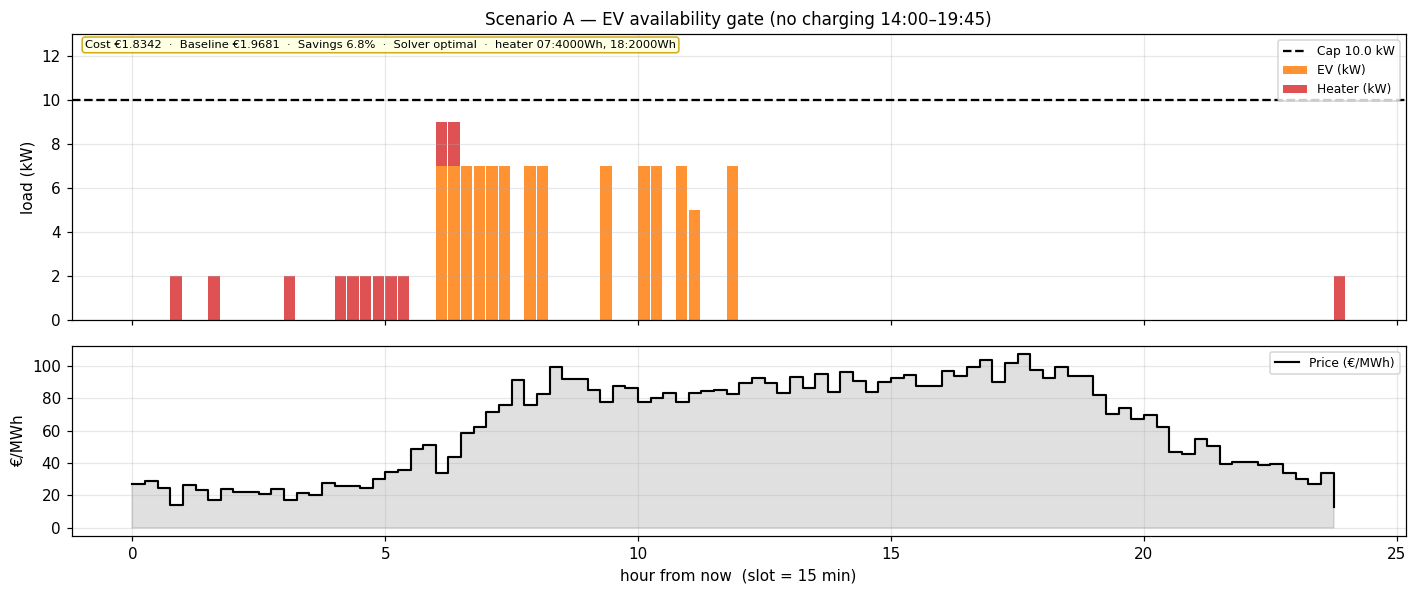

In [2]:
prices_A = make_de_price_curve(seed=1)
now_A = _utc(14)

sched_A = solve_receding_horizon(
    now_A, prices_A, horizon_slots=96, remaining_ev_kwh=24.0,
)

ev = np.asarray(sched_A.ev_power_kw)
print(f"EV [14:00–20:00] kWh = {ev[:24].sum() * SLOT_H:.3f}  (must be 0)")
print(f"EV [20:00–07:00] kWh = {ev[24:68].sum() * SLOT_H:.3f}  (full need)")
print(f"EV [07:00–14:00] kWh = {ev[68:].sum() * SLOT_H:.3f}  (must be 0)")
print(f"Heater windows  kWh = {sched_A.heater_window_kwh}")

assert ev[:24].sum() < 1e-6
assert ev[68:].sum() < 1e-6
assert abs(ev.sum() * SLOT_H - 24.0) < 1e-3

fig_A = plot_schedule(
    sched_A, prices_A,
    title="Scenario A — EV availability gate (no charging 14:00–19:45)",
)
plt.show()


## Scenario B — EV deadline inside vs. outside horizon

Two configurations of the EV deadline against an 8-slot (2 h) horizon:

* **B-near**: now = 05:00, deadline 07:00 (inside the 2 h horizon, slot 8) → C2 hard regime.
* **B-far**: now = 22:00, deadline 07:00 (9 h, well outside the 2 h horizon) → C2 prorated regime with a `deadline_safety = 1.2` margin.

Constraint C2 switches between

> `Δt · Σ_{t<t_d} p_ev[t] + σ_ev ≥ remaining_ev_kwh` &nbsp;&nbsp;(inside)

> `Δt · Σ_t p_ev[t] + σ_ev ≥ remaining_ev_kwh · (H/τ) · γ` &nbsp;&nbsp;(outside).


B-near delivered: 5.000 kWh  (full 5.0 expected)
B-far  delivered: 6.400 kWh  (proportional 24·(2/9)·1.2 ≈ 6.400)


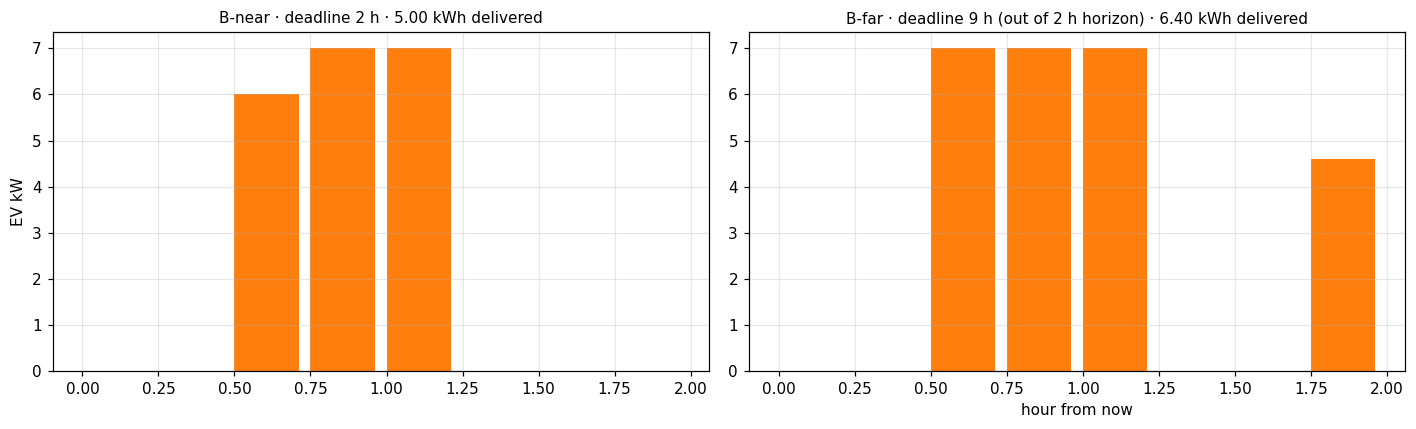

In [3]:
prices_B = np.array([130., 120., 40., 38., 40., 125., 130., 120.])

sched_B_near = solve_receding_horizon(
    _utc(5, 0), prices_B,
    remaining_ev_kwh=5.0, time_to_deadline_h=2.0, horizon_slots=8,
)
sched_B_far = solve_receding_horizon(
    _utc(22, 0), prices_B,
    remaining_ev_kwh=24.0, time_to_deadline_h=9.0, horizon_slots=8,
)

near_kwh = sum(sched_B_near.ev_power_kw) * SLOT_H
far_kwh = sum(sched_B_far.ev_power_kw) * SLOT_H

print(f"B-near delivered: {near_kwh:.3f} kWh  (full 5.0 expected)")
print(f"B-far  delivered: {far_kwh:.3f} kWh  (proportional 24·(2/9)·1.2 ≈ {24*(2/9)*1.2:.3f})")

fig_B, axes = plt.subplots(1, 2, figsize=(13, 4))
hrs = np.arange(8) * SLOT_H
axes[0].bar(hrs, sched_B_near.ev_power_kw, width=SLOT_H*0.85, color=_PALETTE["ev_charger"], align="edge")
axes[0].set_title(f"B-near · deadline 2 h · {near_kwh:.2f} kWh delivered", fontsize=10)
axes[0].set_ylabel("EV kW")
axes[1].bar(hrs, sched_B_far.ev_power_kw, width=SLOT_H*0.85, color=_PALETTE["ev_charger"], align="edge")
axes[1].set_title(f"B-far · deadline 9 h (out of 2 h horizon) · {far_kwh:.2f} kWh delivered", fontsize=10)
axes[1].set_xlabel("hour from now")
plt.tight_layout()
plt.show()


## Scenario C — Heater per-window energy delivery

With `HEATER_DEADLINES = (07:00 → 4 kWh, 18:00 → 2 kWh)` over a flat-price
24 h horizon starting at midnight, both windows lie inside the horizon and
must be fully satisfied. The optimiser is free to spread power however it
likes inside each window — the LP only cares about the integral.

We verify the per-window kWh, then plot the full 24 h schedule.


Window 07:00 delivered: 4.000 kWh  (need 4.0)
Window 18:00 delivered: 2.000 kWh  (need 2.0)


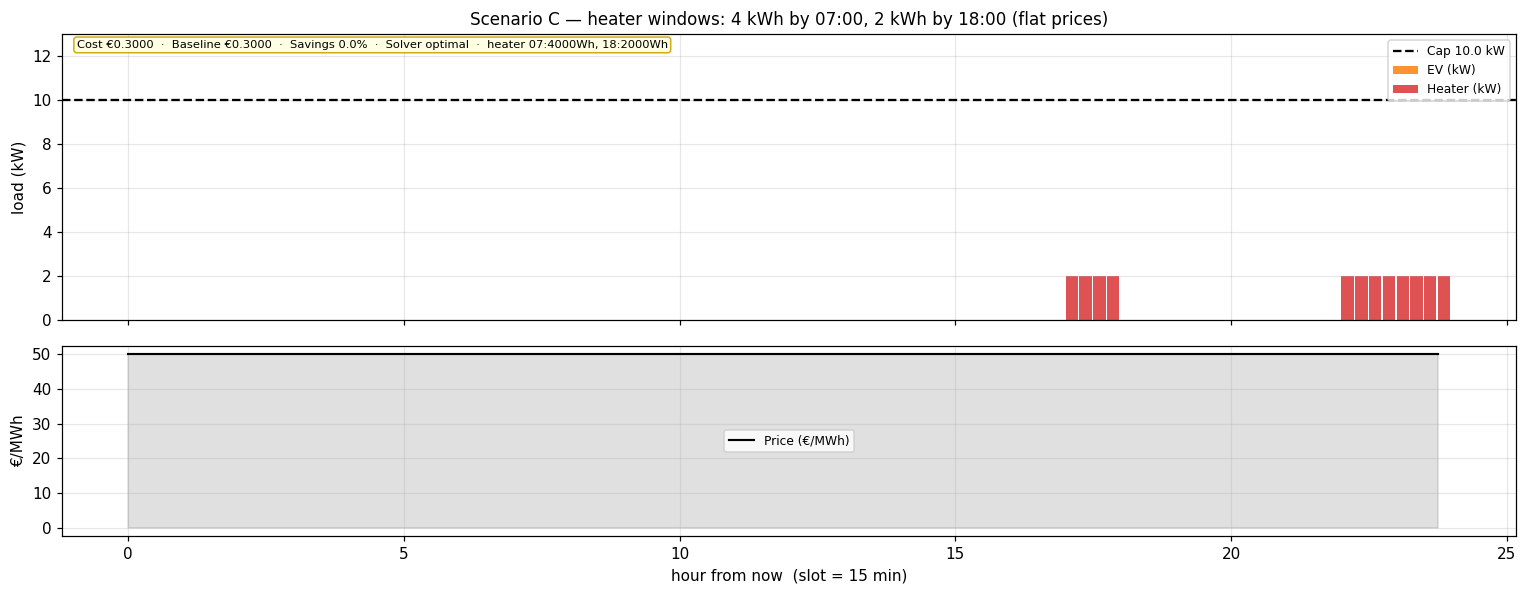

In [4]:
sched_C = solve_receding_horizon(
    _utc(0), np.full(96, 50.0),
    horizon_slots=96, remaining_ev_kwh=0.0,
)

print(f"Window 07:00 delivered: {sched_C.heater_window_kwh[7]:.3f} kWh  (need 4.0)")
print(f"Window 18:00 delivered: {sched_C.heater_window_kwh[18]:.3f} kWh  (need 2.0)")

assert abs(sched_C.heater_window_kwh[7] - 4.0) < 1e-3
assert abs(sched_C.heater_window_kwh[18] - 2.0) < 1e-3

fig_C = plot_schedule(
    sched_C, np.full(96, 50.0),
    title="Scenario C — heater windows: 4 kWh by 07:00, 2 kWh by 18:00 (flat prices)",
    figsize=(14, 5.5),
)
plt.show()


## Scenario D — Heater shapes itself into cheap hours

Same setup as C, but with a price valley between **23:00 and 02:00** (slots
92–95 plus 0–7). The 4 kWh overnight window covers 18:00 → 07:00, so the
heater has 13 h to spend its 4 kWh. The optimiser should concentrate
delivery into the cheap valley.

The daytime 2 kWh window (07:00 → 18:00) has no valley, so we expect
roughly flat delivery there.


Overnight valley kWh / total kWh = 4.000 / 4.000


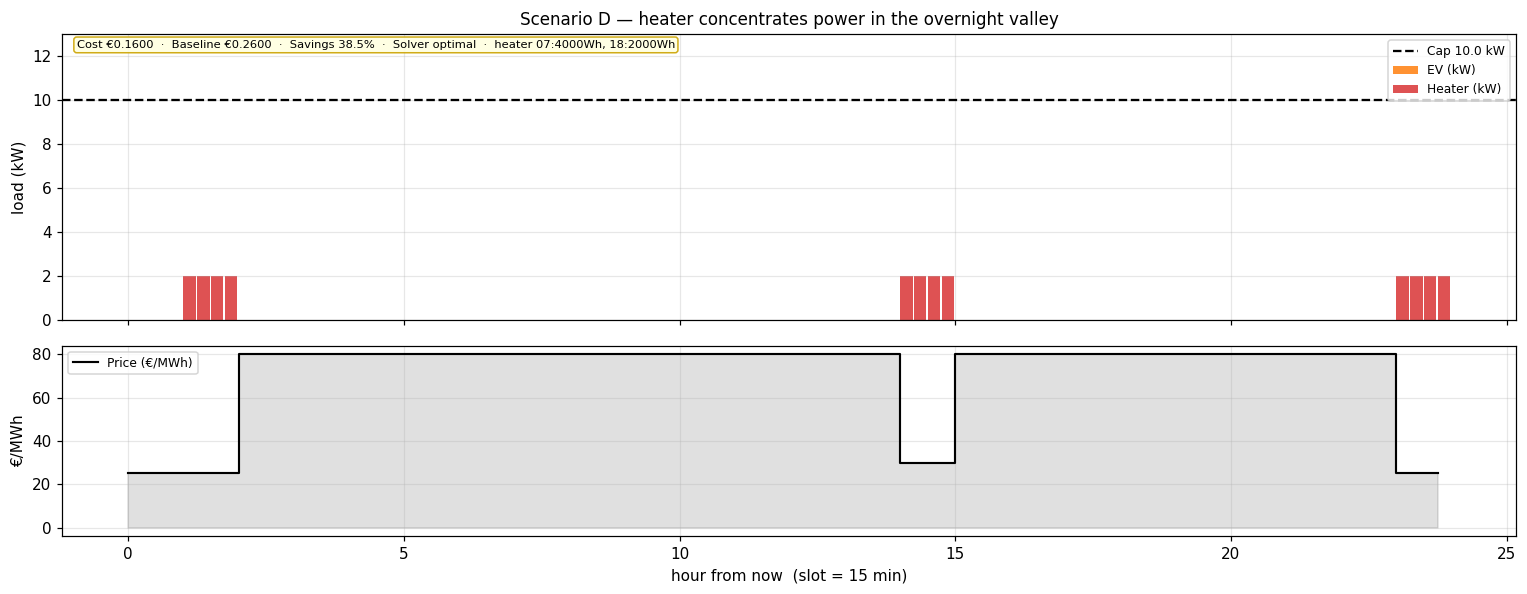

In [5]:
prices_D = np.full(96, 80.0)
prices_D[0:8] = 25.0     # 00:00–02:00 cheap
prices_D[92:96] = 25.0   # 23:00–24:00 cheap
prices_D[56:60] = 30.0   # mid-afternoon (14:00–15:00) cheap

sched_D = solve_receding_horizon(
    _utc(0), prices_D,
    horizon_slots=96, remaining_ev_kwh=0.0,
)

heat = np.asarray(sched_D.heater_power_kw)
overnight_cheap_kwh = (heat[0:8].sum() + heat[92:96].sum()) * SLOT_H
overnight_total_kwh = sched_D.heater_window_kwh[7]
print(f"Overnight valley kWh / total kWh = {overnight_cheap_kwh:.3f} / {overnight_total_kwh:.3f}")

fig_D = plot_schedule(
    sched_D, prices_D,
    title="Scenario D — heater concentrates power in the overnight valley",
    figsize=(14, 5.5),
)
plt.show()


## Scenario E — Power-cap couples EV and heater

Tight cap of **8 kW**: EV (rated 7 kW) plus heater (rated 2 kW) cannot run
flat-out together. We start at 21:00 (inside the EV window), give the EV
12 kWh remaining and the heater its overnight 4 kWh, then watch what the
LP picks during the 21:00–22:00 hour where prices are lowest.


max(EV+heater) = 8.000 kW  (cap 8.0)
EV total kWh    = 12.000
Heater total kWh= 6.000  by window: {7: 4.0, 18: 2.0}


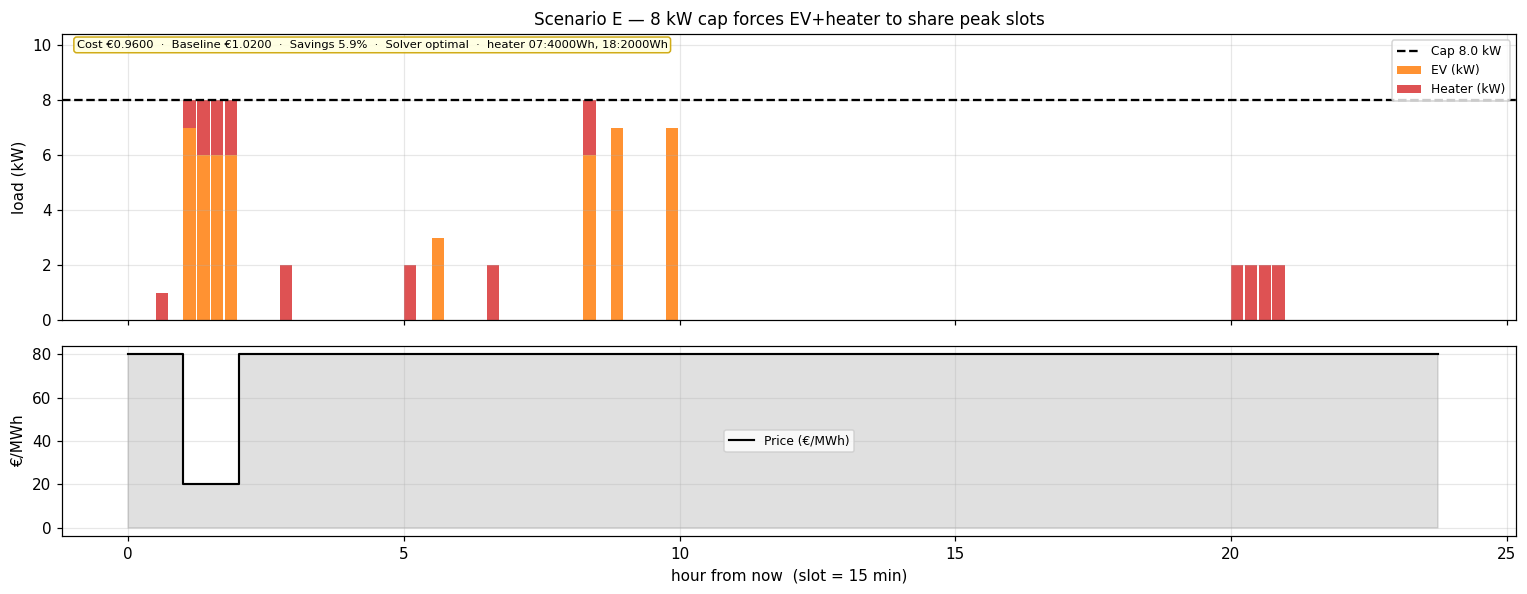

In [6]:
prices_E = np.full(96, 80.0)
prices_E[4:8] = 20.0   # cheapest slot for the start at 21:00 (slots 0..3 = 21:00..22:00, slots 4..7 = 22:00..23:00)

sched_E = solve_receding_horizon(
    _utc(21), prices_E,
    horizon_slots=96, remaining_ev_kwh=12.0, house_cap_kw=8.0,
)

ev = np.asarray(sched_E.ev_power_kw)
heat = np.asarray(sched_E.heater_power_kw)
total = ev + heat
print(f"max(EV+heater) = {total.max():.3f} kW  (cap 8.0)")
assert total.max() <= 8.0 + 1e-6
print(f"EV total kWh    = {ev.sum() * SLOT_H:.3f}")
print(f"Heater total kWh= {heat.sum() * SLOT_H:.3f}  by window: {sched_E.heater_window_kwh}")

fig_E = plot_schedule(
    sched_E, prices_E, cap_kw=8.0,
    title="Scenario E — 8 kW cap forces EV+heater to share peak slots",
    figsize=(14, 5.5),
)
plt.show()


## Scenario F — Committed dishwasher cycle as exogenous load

A dishwasher cycle is already running (committed via the HITL reschedule
flow earlier). It occupies slots 0–7 at 2.5 kW. The cap is **8.5 kW** so
during those 8 slots EV+heater have only `8.5 − 2.5 = 6.0 kW` headroom.

We expect the optimiser to throttle EV+heater accordingly during slots 0–7
and run them freely afterwards.


max load with committed dishwasher = 8.500 kW  (cap 8.5)


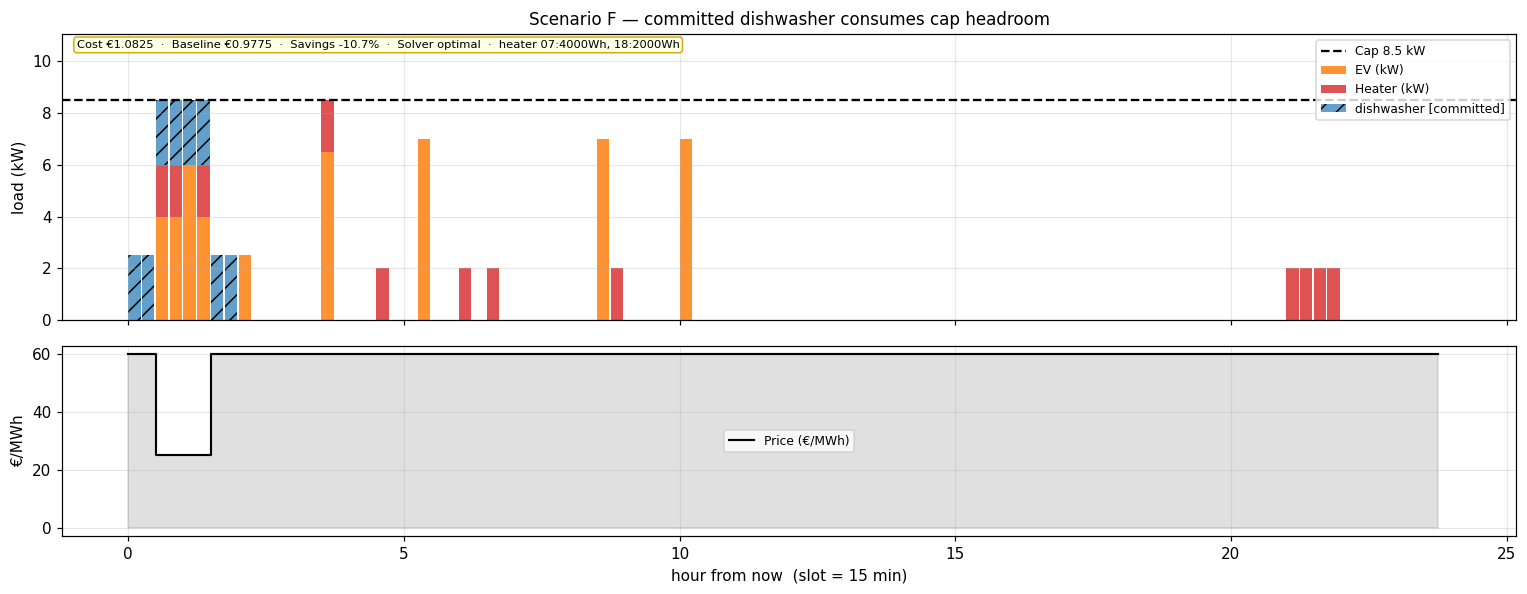

In [7]:
prices_F = np.full(96, 60.0)
prices_F[2:6] = 25.0   # cheapest hour right around the committed cycle

committed_F = [
    ScheduledTask(
        appliance="dishwasher", start_slot=0, slots=8,
        expected_kwh=APPLIANCES["dishwasher"].rated_kw * 8 * SLOT_H,
        committed=True,
    )
]

sched_F = solve_receding_horizon(
    _utc(20), prices_F,
    horizon_slots=96, remaining_ev_kwh=12.0, committed_tasks=committed_F,
    house_cap_kw=8.5,
)

ev = np.asarray(sched_F.ev_power_kw)
heat = np.asarray(sched_F.heater_power_kw)
dish_kw = APPLIANCES["dishwasher"].rated_kw
total_with_dish = ev + heat + np.array(
    [dish_kw if t < 8 else 0.0 for t in range(96)]
)
print(f"max load with committed dishwasher = {total_with_dish.max():.3f} kW  (cap 8.5)")
assert total_with_dish.max() <= 8.5 + 1e-6

fig_F = plot_schedule(
    sched_F, prices_F, cap_kw=8.5,
    title="Scenario F — committed dishwasher consumes cap headroom",
    figsize=(14, 5.5),
)
plt.show()


## Scenario G — Reschedule proposal: dishwasher (accept)

The user starts the **dishwasher at 19:45 UTC** — right before the evening
peak. The agent searches forward up to `HITL_RESCHEDULE_WINDOW_HOURS = 2 h`
for a cheaper start, builds a `RescheduleProposal`, and the HITL policy
formats a question phrased in savings.

Default behaviour in simulation: dishwasher → `accept` (configurable via
`HITL_AUTO_RESPONSES`).


Proposal: shift 75 min → 21:00
  cost_now = €0.7344
  cost_proposed = €0.1250
  savings = €0.6094  (threshold €0.1)

HITL decision: ASK
Question: Postpone dishwasher by 1.2 h to 21:00? You can save €0.61. (accept/decline)


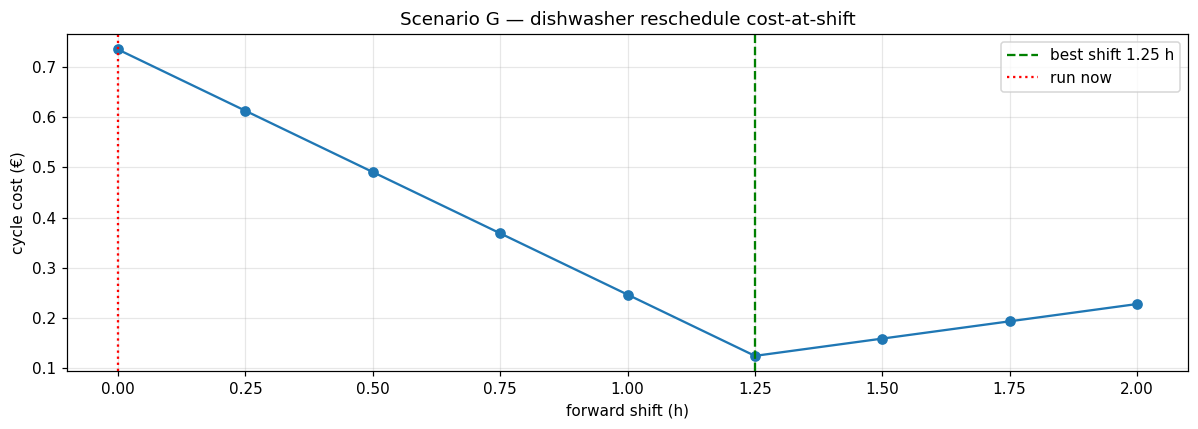

In [8]:
# 24 h price profile with a peak 19:00-21:00 and a deep valley 21:00-23:00.
# Onset is 19:45; the 2 h reschedule window covers up to 21:45, so the
# optimiser can shift into the valley to save money.
prices_G = np.full(96, 80.0)
prices_G[76:84] = 220.0   # 19:00–21:00 peak
prices_G[84:92] = 25.0    # 21:00–23:00 valley
onset_at_G = _utc(19, 45)

# We need the price slice starting at the slot containing onset_at_G.
slot_idx = (onset_at_G.hour * 4 + onset_at_G.minute // 15)
slice_G = np.concatenate([prices_G[slot_idx:], prices_G[:slot_idx]])

prop_G = _propose_for_onset(
    appliance="dishwasher",
    onset_at=onset_at_G,
    prices=slice_G,
    cycle_slots=APPLIANCES["dishwasher"].cycle_slots,
    rated_kw=APPLIANCES["dishwasher"].rated_kw,
    horizon_slots=96,
)

decision_G = decide_reschedule(prop_G)
print(f"Proposal: shift {prop_G.shift_minutes:.0f} min → {prop_G.proposed_start_at.strftime('%H:%M')}")
print(f"  cost_now = €{prop_G.cost_now_eur:.4f}")
print(f"  cost_proposed = €{prop_G.cost_proposed_eur:.4f}")
print(f"  savings = €{prop_G.savings_eur:.4f}  (threshold €{HITL_RESCHEDULE_MIN_SAVINGS_EUR})")
print(f"\nHITL decision: {decision_G.action.upper()}")
print(f"Question: {decision_G.question}")

# Visualise the cycle's energy footprint at each candidate start.
window_slots = int(HITL_RESCHEDULE_WINDOW_HOURS * 60.0 / SLOT_MINUTES)
candidates = list(range(0, window_slots + 1))
costs = [
    float(slice_G[s : s + APPLIANCES["dishwasher"].cycle_slots].sum()
          * APPLIANCES["dishwasher"].rated_kw * _PER_SLOT)
    for s in candidates
]
fig_G, ax = plt.subplots(figsize=(11, 4))
ax.plot([s * SLOT_H for s in candidates], costs, "o-", color=_PALETTE["dishwasher"])
best = candidates[int(np.argmin(costs))]
ax.axvline(best * SLOT_H, color="green", ls="--", label=f"best shift {best * SLOT_H:.2f} h")
ax.axvline(0, color="red", ls=":", label="run now")
ax.set_xlabel("forward shift (h)")
ax.set_ylabel("cycle cost (€)")
ax.set_title("Scenario G — dishwasher reschedule cost-at-shift")
ax.legend()
plt.tight_layout()
plt.show()


## Scenario H — Reschedule proposal: washing machine (decline)

Same machinery as G, but the appliance is the **washing machine** and the
default `HITL_AUTO_RESPONSES["washing_machine"] = "decline"` runs the cycle
at the original onset time. The savings number is still computed and
logged so we can report the *missed* savings later.


In [9]:
# Mid-morning peak (10:30–12:30) followed by a midday valley (12:30–14:30).
# Onset is 10:30 — shifting into the valley would save €€, but the simulated
# user declines.
prices_H = np.full(96, 80.0)
prices_H[42:50] = 200.0   # 10:30–12:30 peak
prices_H[50:58] = 30.0    # 12:30–14:30 valley
onset_at_H = _utc(10, 30)

slot_idx_H = (onset_at_H.hour * 4 + onset_at_H.minute // 15)
slice_H = np.concatenate([prices_H[slot_idx_H:], prices_H[:slot_idx_H]])

prop_H = _propose_for_onset(
    appliance="washing_machine",
    onset_at=onset_at_H,
    prices=slice_H,
    cycle_slots=APPLIANCES["washing_machine"].cycle_slots,
    rated_kw=APPLIANCES["washing_machine"].rated_kw,
    horizon_slots=96,
)

# Even though the proposal exists, the simulated user declines it. We
# emulate the digital twin's behaviour by reading HITL_AUTO_RESPONSES.
from aerogrid.config import HITL_AUTO_RESPONSES
sim_answer = HITL_AUTO_RESPONSES["washing_machine"]
decision_H = decide_reschedule(prop_H)
print(f"Proposal: shift {prop_H.shift_minutes:.0f} min → {prop_H.proposed_start_at.strftime('%H:%M')}")
print(f"  savings = €{prop_H.savings_eur:.4f}")
print(f"HITL decision: {decision_H.action.upper()} — would ask: {decision_H.question[:80] + '...' if len(decision_H.question) > 80 else decision_H.question}")
print(f"Simulated user (auto_confirm=True) reply: {sim_answer!r}")
print(f"→ washing machine runs at the original onset time {onset_at_H.strftime('%H:%M')}; missed savings €{prop_H.savings_eur:.4f}.")


Proposal: shift 120 min → 12:30
  savings = €0.6120
HITL decision: ASK — would ask: Postpone washing_machine by 2.0 h to 12:30? You can save €0.61. (accept/decline)
Simulated user (auto_confirm=True) reply: 'decline'
→ washing machine runs at the original onset time 10:30; missed savings €0.6120.


## Scenario I — HITL throughput stress test

We slam the system with **8 onsets in a 2-hour window** (alternating
dishwasher and washing machine) and run each through the propose →
decide_reschedule → simulated-user pipeline. The HITL gate's *AUTO*
decisions short-circuit small savings, so only the proposals that genuinely
matter make it past the threshold.

The summary table records: per-onset shift, savings, threshold filter,
HITL decision (`ask`/`auto`), and the simulated user's reply.


,appliance,onset,best_shift_min,cost_now_€,cost_best_€,savings_€,above_threshold,decision,sim_user
0,dishwasher,18:00,120.0,0.4376,0.3041,0.1335,True,ask,accept
1,washing_machine,18:30,120.0,0.3076,0.1959,0.1117,True,ask,decline
2,dishwasher,19:00,120.0,0.3948,0.2062,0.1886,True,ask,accept
3,washing_machine,19:15,120.0,0.2799,0.1443,0.1356,True,ask,decline
4,dishwasher,19:45,120.0,0.3226,0.1659,0.1567,True,ask,accept
5,washing_machine,20:00,120.0,0.2425,0.1236,0.1188,True,ask,decline
6,dishwasher,20:30,120.0,0.2530,0.1315,0.1215,True,ask,accept
7,washing_machine,20:45,105.0,0.1833,0.0981,0.0852,False,auto,decline


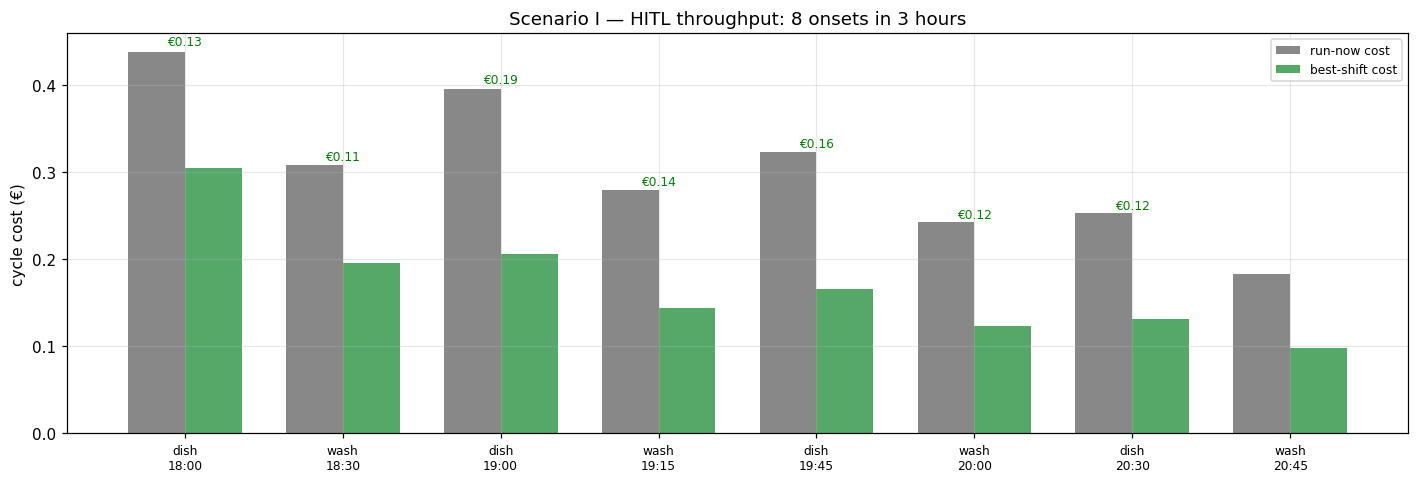


Total potential savings: €1.0516
Of which forwarded to HITL (≥ threshold): €0.9664
Realised savings (sim user accepts dishwasher, declines washer): €0.6003


In [10]:
import itertools
prices_I = make_de_price_curve(seed=3, peak1_h=8.0, peak2_h=19.0)

onsets_I = []
for k, (h, m) in enumerate(
    [(18, 0), (18, 30), (19, 0), (19, 15), (19, 45), (20, 0), (20, 30), (20, 45)]
):
    appliance = "dishwasher" if k % 2 == 0 else "washing_machine"
    onsets_I.append((appliance, _utc(h, m)))

rows = []
for app, onset_at in onsets_I:
    slot_idx = (onset_at.hour * 4 + onset_at.minute // 15)
    slice_p = np.concatenate([prices_I[slot_idx:], prices_I[:slot_idx]])
    spec = APPLIANCES[app]
    p = _propose_for_onset(
        app, onset_at, slice_p,
        cycle_slots=spec.cycle_slots, rated_kw=spec.rated_kw, horizon_slots=96,
    )
    decision = decide_reschedule(p)
    sim_answer = HITL_AUTO_RESPONSES[app]
    rows.append({
        "appliance": app,
        "onset": onset_at.strftime("%H:%M"),
        "best_shift_min": round(p.shift_minutes, 0),
        "cost_now_€": round(p.cost_now_eur, 4),
        "cost_best_€": round(p.cost_proposed_eur, 4),
        "savings_€": round(p.savings_eur, 4),
        "above_threshold": p.savings_eur >= HITL_RESCHEDULE_MIN_SAVINGS_EUR,
        "decision": decision.action,
        "sim_user": sim_answer,
    })

df_I = pd.DataFrame(rows)
display(df_I)

# Plot cost-now vs cost-best per onset.
fig_I, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(df_I))
ax.bar(x - 0.18, df_I["cost_now_€"], width=0.36, color="#888", label="run-now cost")
ax.bar(x + 0.18, df_I["cost_best_€"], width=0.36, color="#55a868", label="best-shift cost")
for i, row in df_I.iterrows():
    if row["above_threshold"]:
        ax.text(i, max(row["cost_now_€"], row["cost_best_€"]) * 1.02,
                f"€{row['savings_€']:.2f}", ha="center", fontsize=8, color="green")
ax.set_xticks(x)
ax.set_xticklabels([f"{r['appliance'][:4]}\n{r['onset']}" for _, r in df_I.iterrows()], fontsize=8)
ax.set_ylabel("cycle cost (€)")
ax.set_title("Scenario I — HITL throughput: 8 onsets in 3 hours")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"\nTotal potential savings: €{df_I['savings_€'].sum():.4f}")
ask_total = df_I[df_I['decision'] == 'ask']['savings_€'].sum()
print(f"Of which forwarded to HITL (≥ threshold): €{ask_total:.4f}")
print(f"Realised savings (sim user accepts dishwasher, declines washer): "
      f"€{df_I[(df_I['sim_user']=='accept')&(df_I['decision']=='ask')]['savings_€'].sum():.4f}")


## Scenario J — Horizon sensitivity

We solve the same 24 h day with horizons of **6 h, 12 h, and 24 h**, all
evaluated at midnight. A short horizon cannot see the next deadline far
ahead, so it relies on the proportional-EV and proportional-heater
fallbacks; a long horizon sees both deadlines and can plan globally.

We report:
- expected cost
- baseline cost
- savings %
- LP wall-clock time

The 24 h LP should be only a few times slower than the 6 h LP because the
problem has no integer variables.


,horizon_h,horizon_slots,expected_cost_€,baseline_cost_€,savings_%,ev_total_kWh,heater_kWh_07,heater_kWh_18,solve_ms,status
0,6,24,0.5396,0.6042,10.7,24.686,4.0,0.0,13.9,optimal
1,12,48,0.6665,0.7526,11.4,24.000,4.0,2.0,21.7,optimal
2,24,96,0.6665,0.7526,11.4,24.000,4.0,2.0,88.6,optimal


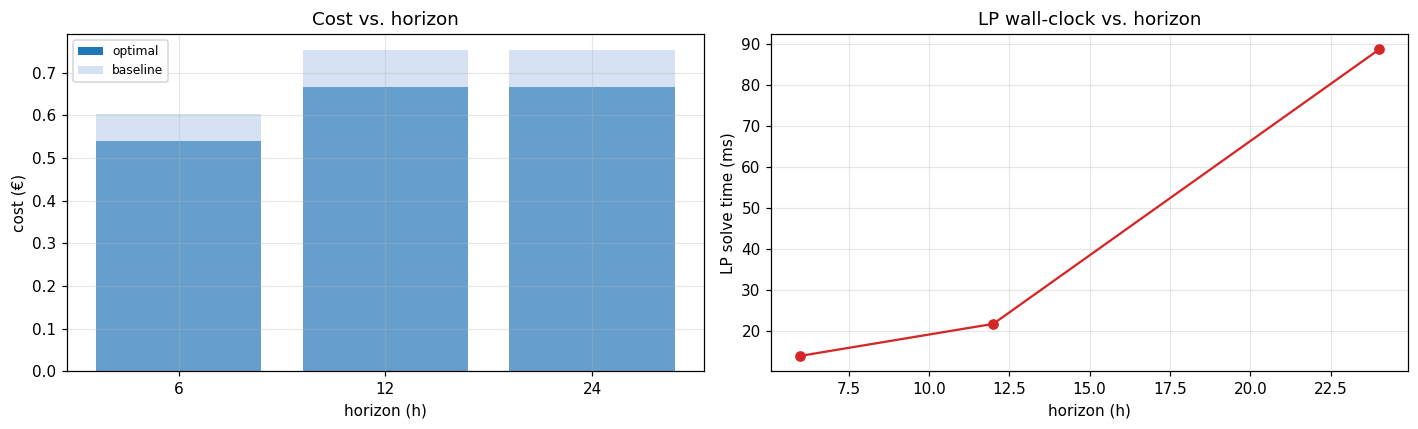

In [11]:
prices_J = make_de_price_curve(seed=4)

results = []
for h in (6, 12, 24):
    slots = h * 4
    p_slice = prices_J[:slots]
    t0 = time.perf_counter()
    s = solve_receding_horizon(
        _utc(0), p_slice, horizon_slots=slots, remaining_ev_kwh=24.0,
    )
    dt_ms = (time.perf_counter() - t0) * 1000.0
    results.append({
        "horizon_h": h,
        "horizon_slots": slots,
        "expected_cost_€": round(s.expected_cost, 4),
        "baseline_cost_€": round(s.baseline_cost, 4),
        "savings_%": round(s.savings() * 100, 1),
        "ev_total_kWh": round(sum(s.ev_power_kw) * SLOT_H, 3),
        "heater_kWh_07": round(s.heater_window_kwh.get(7, 0.0), 3),
        "heater_kWh_18": round(s.heater_window_kwh.get(18, 0.0), 3),
        "solve_ms": round(dt_ms, 1),
        "status": s.solver_status,
    })
df_J = pd.DataFrame(results)
display(df_J)

fig_J, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(df_J["horizon_h"].astype(str), df_J["expected_cost_€"],
            color="#1f77b4", label="optimal")
axes[0].bar(df_J["horizon_h"].astype(str), df_J["baseline_cost_€"],
            color="#aec7e8", alpha=0.5, label="baseline")
axes[0].set_xlabel("horizon (h)")
axes[0].set_ylabel("cost (€)")
axes[0].set_title("Cost vs. horizon")
axes[0].legend(fontsize=8)
axes[1].plot(df_J["horizon_h"], df_J["solve_ms"], "o-", color="#d62728")
axes[1].set_xlabel("horizon (h)")
axes[1].set_ylabel("LP solve time (ms)")
axes[1].set_title("LP wall-clock vs. horizon")
plt.tight_layout()
plt.show()


## Scenario K — Heater infeasibility → soft slack

We override `HEATER_DEADLINES` with a deliberately impossible spec:
**100 kWh required by 07:00**. The heater rated power is 2 kW so the
maximum it can deliver in any 13 h overnight window is 26 kWh — slack must
absorb the rest. The LP must remain feasible (`status="optimal"`) because
the slack penalty is dominated only by the cost we *cannot* shave.


Heater max power across horizon: 2.000 kW  (rated 2.0)
Window 07:00 delivered: 26.000 kWh  (asked 100; physical max ≤ 26)
Solver status: optimal


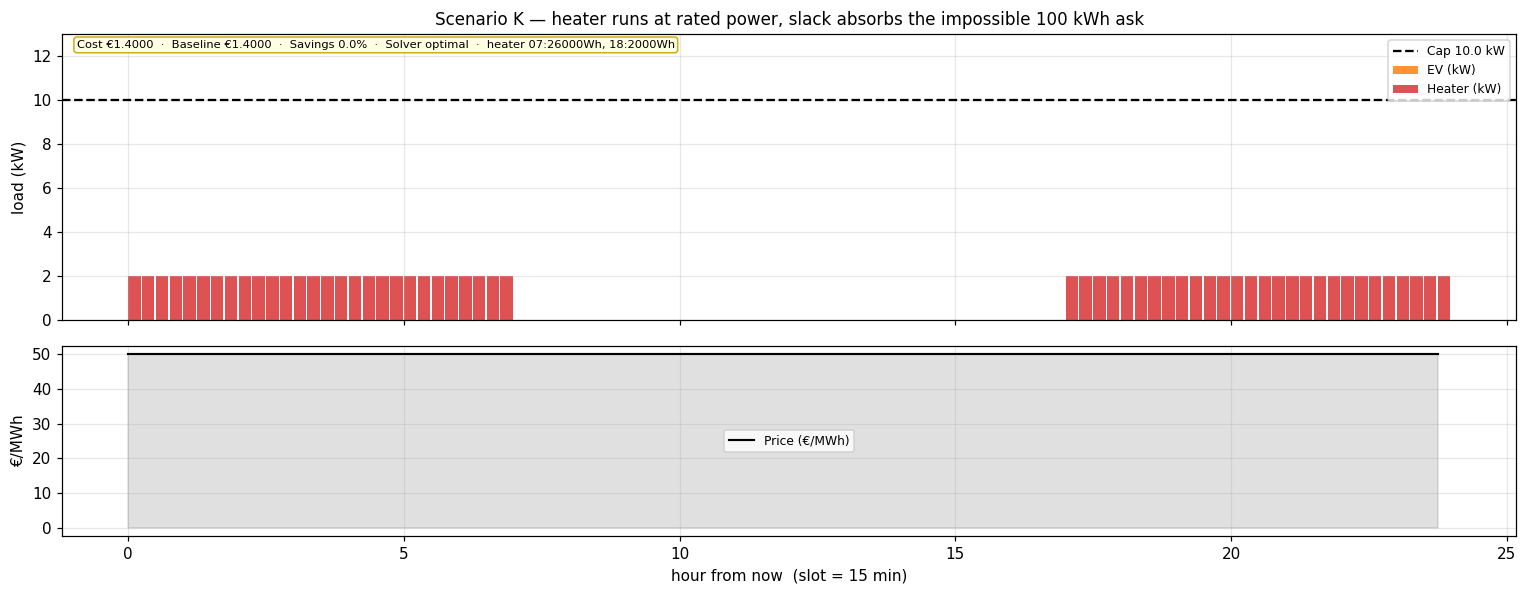

In [12]:
custom = (
    HeaterEnergyDeadline(hour=7, kwh_required=100.0),
    HeaterEnergyDeadline(hour=18, kwh_required=2.0),
)
prices_K = np.full(96, 50.0)

sched_K = solve_receding_horizon(
    _utc(0), prices_K,
    horizon_slots=96, remaining_ev_kwh=0.0,
    heater_deadlines=custom,
)
heat = np.asarray(sched_K.heater_power_kw)
print(f"Heater max power across horizon: {heat.max():.3f} kW  (rated 2.0)")
print(f"Window 07:00 delivered: {sched_K.heater_window_kwh[7]:.3f} kWh  (asked 100; physical max ≤ 26)")
print(f"Solver status: {sched_K.solver_status}")
assert sched_K.solver_status in ("optimal", "optimal_inaccurate")

fig_K = plot_schedule(
    sched_K, prices_K,
    title="Scenario K — heater runs at rated power, slack absorbs the impossible 100 kWh ask",
    figsize=(14, 5.5),
)
plt.show()


## Scenario L — Joint MIP vs price-only reschedule (cap binding)

This scenario shows *why* the optimiser solves the reschedule jointly with
the EV / heater plan instead of using a price-only shift score.

We start at **21:00 UTC** (inside the EV charging window) with:

* the EV needing **12 kWh** by 07:00 (deadline well outside the horizon),
* a **tight 8 kW house cap**,
* a sharp price valley at slots **4–7** (cheap hour right after onset),
* the user starting the **dishwasher at 21:00**.

The price-only logic (`_propose_for_onset`) sees the cheapest 8-slot start
and recommends shifting the cycle into that valley, ignoring the EV. But
moving the dishwasher into the valley would force the EV to share the cap
with it — costing the EV its cheap charging slots and forcing it to charge
later at higher prices.

The joint MIP (the new `solve_receding_horizon` with `pending_cycles=[…]`)
co-optimises the cycle placement with the EV / heater plan and the cap.

The two approaches end up disagreeing on the slot, and the joint MIP
delivers a **lower plan-level cost** because it sees the trade-off.


──────────────────────────────────────────────────────────────
Price-only naive shift          : slot 4 (+1.00 h)
  isolated cycle cost           : €0.1000   ← what the user is told
  plan-level cost if committed  : €1.0975   ← what the user actually pays

Joint MIP optimal shift         : slot 8 (+2.00 h)
  plan-level cost               : €1.0125   ← lower!

Δ = €+0.0850  (+7.7% relative)
──────────────────────────────────────────────────────────────


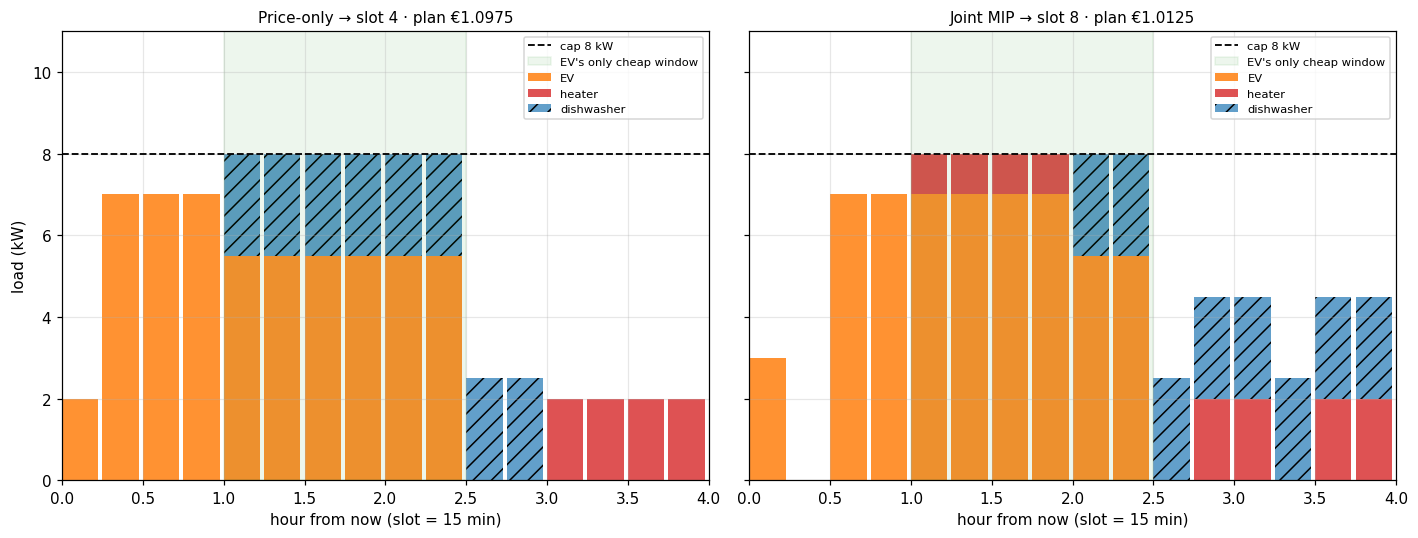

In [13]:
# Setup: tight EV deadline (2.5 h, 10 slots ahead) + tight cap (8 kW).
# The EV is in the *only* cheap window (slots 4-9, price 10) and needs
# enough kWh that any cycle overlap forces it onto expensive slots.
#
# Price-only logic picks the cheapest 8-slot run for the cycle (slot 4),
# but that overlaps the EV's only cheap window, knocking EV power down
# from 7 kW to 5.5 kW for those slots and pushing the missing kWh into
# the expensive 100 €/MWh slots 0-3.
#
# Joint MIP sees this trade-off and shifts the cycle to slot 8, where
# the cycle costs slightly more but the EV gets to use the full cheap
# window unimpeded.
prices_L = np.full(96, 60.0)
prices_L[0:4]  = 100.0      # 04:30-05:30 expensive
prices_L[4:10] = 10.0       # 05:30-07:00 deeply cheap (EV's only chance)
prices_L[10:16] = 50.0      # 07:00-08:30 medium

now_L = _utc(4, 30)         # 04:30 UTC, EV deadline at 07:00 (slot 10)

spec = APPLIANCES["dishwasher"]
window_slots = int(HITL_RESCHEDULE_WINDOW_HOURS * 60.0 / SLOT_MINUTES)
last_start = min(window_slots, 96 - spec.cycle_slots)

# (1) Price-only proposal — the "naive" shift score we used pre-MIP.
slice_L = prices_L[:96]
naive = _propose_for_onset(
    "dishwasher", now_L, slice_L,
    cycle_slots=spec.cycle_slots, rated_kw=spec.rated_kw, horizon_slots=96,
)

# (2) Joint MIP — schedule with pending dishwasher and tight EV deadline.
def _solve_with_cycle_at(slot: int):
    return solve_receding_horizon(
        now_L, prices_L, horizon_slots=96,
        remaining_ev_kwh=14.0, time_to_deadline_h=2.5, house_cap_kw=8.0,
        pending_cycles=[PendingCycle(
            appliance="dishwasher", cycle_slots=spec.cycle_slots,
            rated_kw=spec.rated_kw,
            earliest_start_slot=slot, latest_start_slot=slot,
        )],
    )

sched_joint = solve_receding_horizon(
    now_L, prices_L, horizon_slots=96,
    remaining_ev_kwh=14.0, time_to_deadline_h=2.5, house_cap_kw=8.0,
    pending_cycles=[PendingCycle(
        appliance="dishwasher", cycle_slots=spec.cycle_slots,
        rated_kw=spec.rated_kw, earliest_start_slot=0,
        latest_start_slot=last_start,
    )],
)
joint_slot = sched_joint.cycle_starts["dishwasher"]
joint_cost = sched_joint.expected_cost

# (3) Plan-level cost the user would actually realise if the price-only
# logic decided — pin the cycle at the naive slot and re-solve.
naive_slot = int(round((naive.proposed_start_at - now_L).total_seconds() / 60.0 / SLOT_MINUTES))
sched_pin_naive = _solve_with_cycle_at(naive_slot)
naive_realised_cost = sched_pin_naive.expected_cost

print("─" * 62)
print(f"Price-only naive shift          : slot {naive_slot} (+{naive_slot*SLOT_H:.2f} h)")
print(f"  isolated cycle cost           : €{naive.cost_proposed_eur:.4f}   ← what the user is told")
print(f"  plan-level cost if committed  : €{naive_realised_cost:.4f}   ← what the user actually pays")
print()
print(f"Joint MIP optimal shift         : slot {joint_slot} (+{joint_slot*SLOT_H:.2f} h)")
print(f"  plan-level cost               : €{joint_cost:.4f}   ← lower!")
print()
delta = naive_realised_cost - joint_cost
pct = (1 - joint_cost / max(naive_realised_cost, 1e-9)) * 100
print(f"Δ = €{delta:+.4f}  ({pct:+.1f}% relative)")
print("─" * 62)

# Plot the two outcomes side by side, zoomed on the first 4 hours.
fig_L, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, sched, slot, title in [
    (axes[0], sched_pin_naive, naive_slot,
     f"Price-only → slot {naive_slot} · plan €{naive_realised_cost:.4f}"),
    (axes[1], sched_joint, joint_slot,
     f"Joint MIP → slot {joint_slot} · plan €{joint_cost:.4f}"),
]:
    T = sched.horizon_slots
    hrs = np.arange(T) * SLOT_H
    ev = np.asarray(sched.ev_power_kw)
    heat = np.asarray(sched.heater_power_kw)
    dish = np.zeros(T)
    dish[slot : slot + spec.cycle_slots] = spec.rated_kw
    ax.bar(hrs, ev, width=SLOT_H * 0.9, color=_PALETTE["ev_charger"],
           label="EV", align="edge", alpha=0.85)
    ax.bar(hrs, heat, width=SLOT_H * 0.9, bottom=ev,
           color=_PALETTE["heater"], label="heater", align="edge", alpha=0.8)
    ax.bar(hrs, dish, width=SLOT_H * 0.9, bottom=ev + heat,
           color=_PALETTE["dishwasher"], hatch="//", label="dishwasher",
           align="edge", alpha=0.7)
    ax.axhline(8.0, color="black", ls="--", lw=1.2, label="cap 8 kW")
    # Shade EV's cheap window (slots 4-9) for context.
    ax.axvspan(4 * SLOT_H, 10 * SLOT_H, alpha=0.07, color="green",
               label="EV's only cheap window")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f"hour from now (slot = {SLOT_MINUTES} min)")
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 11)
    ax.legend(fontsize=7.5, loc="upper right")
axes[0].set_ylabel("load (kW)")
plt.tight_layout()
plt.show()


## Scenario M — Re-nudge before start ("postpone for another hour")

This scenario exercises the new behaviour: **any cycle that has not started
yet remains replannable**.

Flow:

1. At 20:00 the user starts the dishwasher. The joint solver proposes a +1 h
   shift (slot 4). We commit that deferred start.
2. Fifteen minutes later (20:15), a *different* appliance onset appears
   (washing machine). We now include:
   - the new onset,
   - the deferred dishwasher as a synthetic replannable onset
     (`CommitTracker.replannable_onsets`),
   and re-solve jointly.
3. The solver nudges dishwasher again to a later slot (another hour-like move)
   while also placing washing machine, all under the same cap.


First plan (20:00):
  dishwasher slot = 4  (+1.00 h)
Second plan (20:15) with new washing-machine onset:
  dishwasher slot = 8  (+2.00 h from now)
  washing machine slot = 0  (+0.00 h from now)
  dishwasher additional nudge = 1.25 h


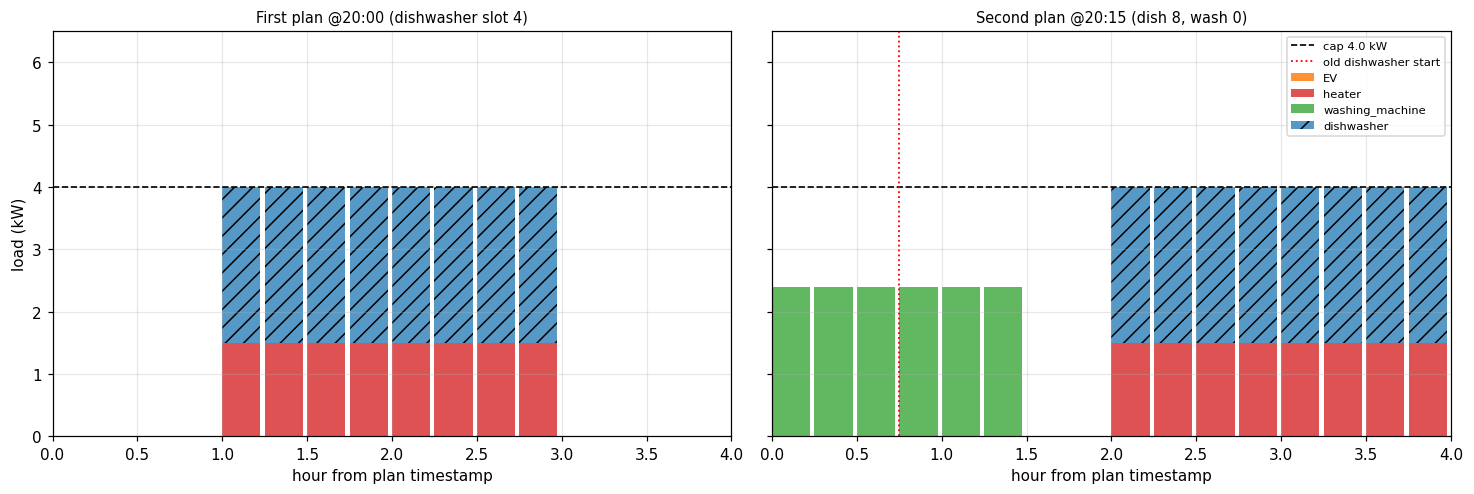

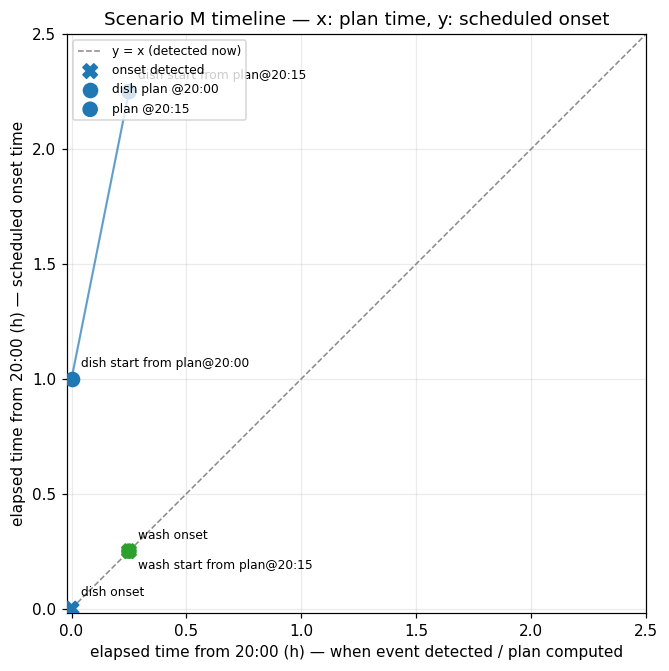

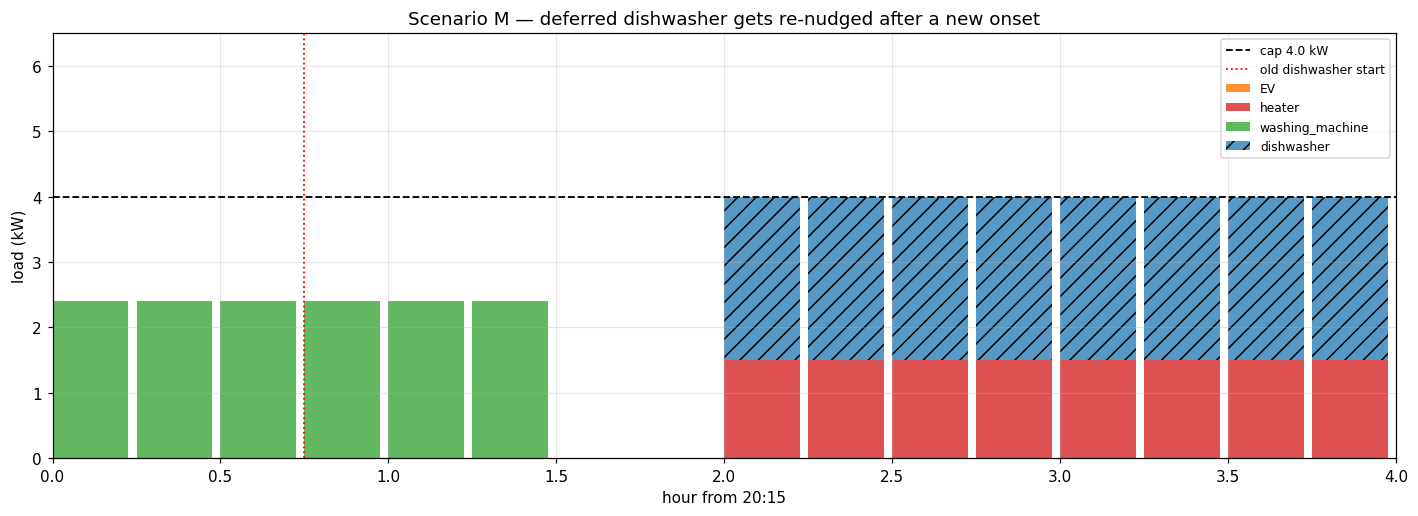

In [14]:
now0 = _utc(20, 0)
spec_d = APPLIANCES["dishwasher"]
spec_w = APPLIANCES["washing_machine"]

# Step 1 — first onset (dishwasher only): best slot is +1 h.
prices_M0 = np.full(96, 80.0)
prices_M0[4:12] = 20.0
sched_M0 = solve_receding_horizon(
    now0, prices_M0,
    horizon_slots=96, remaining_ev_kwh=0.0, house_cap_kw=4.0,
    pending_cycles=[PendingCycle(
        appliance="dishwasher",
        cycle_slots=spec_d.cycle_slots,
        rated_kw=spec_d.rated_kw,
        earliest_start_slot=0, latest_start_slot=8,
    )],
)
first_slot = int(sched_M0.cycle_starts["dishwasher"])

commit = CommitTracker()
cycle_kwh_d = spec_d.rated_kw * spec_d.cycle_slots * SLOT_H
commit.adopt_cycle_start(
    appliance="dishwasher",
    slots=spec_d.cycle_slots,
    expected_kwh=cycle_kwh_d,
    start_at=now0 + timedelta(minutes=SLOT_MINUTES * first_slot),
    now=now0,
)

# Step 2 — 15 min later, another onset appears (washing machine).
now1 = now0 + timedelta(minutes=15)
replannable = commit.replannable_onsets(now1)
assert any(o.appliance == "dishwasher" for o in replannable), "Deferred dishwasher must stay replannable."

prices_M1 = np.full(96, 80.0)
prices_M1[3:8] = 200.0
prices_M1[8:16] = 20.0

sched_M1 = solve_receding_horizon(
    now1, prices_M1,
    horizon_slots=96, remaining_ev_kwh=0.0, house_cap_kw=4.0,
    pending_cycles=[
        PendingCycle(
            appliance="dishwasher",
            cycle_slots=spec_d.cycle_slots,
            rated_kw=spec_d.rated_kw,
            earliest_start_slot=0, latest_start_slot=8,
        ),
        PendingCycle(
            appliance="washing_machine",
            cycle_slots=spec_w.cycle_slots,
            rated_kw=spec_w.rated_kw,
            earliest_start_slot=0, latest_start_slot=8,
        ),
    ],
)

second_slot = int(sched_M1.cycle_starts["dishwasher"])
wm_slot = int(sched_M1.cycle_starts["washing_machine"])

print("First plan (20:00):")
print(f"  dishwasher slot = {first_slot}  (+{first_slot*SLOT_H:.2f} h)")
print("Second plan (20:15) with new washing-machine onset:")
print(f"  dishwasher slot = {second_slot}  (+{second_slot*SLOT_H:.2f} h from now)")
print(f"  washing machine slot = {wm_slot}  (+{wm_slot*SLOT_H:.2f} h from now)")
print(f"  dishwasher additional nudge = {(second_slot - (first_slot-1))*SLOT_H:.2f} h")

# From 20:15, the original +1 h dishwasher start corresponds to slot 3.
orig_slot_from_now1 = first_slot - 1
assert second_slot >= orig_slot_from_now1 + 4, "Expected dishwasher to be nudged by ~another hour."

# Visualise first and second plans side-by-side.
T = sched_M1.horizon_slots
hrs = np.arange(T) * SLOT_H

dish_first = np.zeros(T); dish_first[first_slot:first_slot + spec_d.cycle_slots] = spec_d.rated_kw
dish_second = np.zeros(T); dish_second[second_slot:second_slot + spec_d.cycle_slots] = spec_d.rated_kw
wash_second = np.zeros(T); wash_second[wm_slot:wm_slot + spec_w.cycle_slots] = spec_w.rated_kw

fig_M_plans, axes = plt.subplots(1, 2, figsize=(13.5, 4.6), sharey=True)
for ax, title, ev_arr, heat_arr, dish_arr, wash_arr, mark_old in [
    (
        axes[0],
        f"First plan @20:00 (dishwasher slot {first_slot})",
        np.asarray(sched_M0.ev_power_kw),
        np.asarray(sched_M0.heater_power_kw),
        dish_first,
        np.zeros(T),
        None,
    ),
    (
        axes[1],
        f"Second plan @20:15 (dish {second_slot}, wash {wm_slot})",
        np.asarray(sched_M1.ev_power_kw),
        np.asarray(sched_M1.heater_power_kw),
        dish_second,
        wash_second,
        orig_slot_from_now1 * SLOT_H,
    ),
]:
    ax.bar(hrs, ev_arr, width=SLOT_H*0.9, color=_PALETTE["ev_charger"], alpha=0.85, label="EV", align="edge")
    ax.bar(hrs, heat_arr, width=SLOT_H*0.9, bottom=ev_arr, color=_PALETTE["heater"], alpha=0.8, label="heater", align="edge")
    ax.bar(hrs, wash_arr, width=SLOT_H*0.9, bottom=ev_arr+heat_arr, color=_PALETTE["washing_machine"], alpha=0.75, label="washing_machine", align="edge")
    ax.bar(hrs, dish_arr, width=SLOT_H*0.9, bottom=ev_arr+heat_arr+wash_arr, color=_PALETTE["dishwasher"], hatch="//", alpha=0.75, label="dishwasher", align="edge")
    ax.axhline(4.0, color="black", ls="--", lw=1.1, label="cap 4.0 kW")
    if mark_old is not None:
        ax.axvline(mark_old, color="red", ls=":", lw=1.2, label="old dishwasher start")
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 6.5)
    ax.set_xlabel("hour from plan timestamp")
    ax.set_title(title, fontsize=9.5)
axes[0].set_ylabel("load (kW)")
axes[1].legend(fontsize=7.5, loc="upper right")
plt.tight_layout()
plt.show()

# Timeline view (requested): x = elapsed replan/detection time,
# y = elapsed scheduled start time. Onset detections lie on y=x.
t0 = now0
t_event_dish = now0
t_event_wash = now1
t_plan1_dish = now0 + timedelta(minutes=SLOT_MINUTES * first_slot)
t_plan2_dish = now1 + timedelta(minutes=SLOT_MINUTES * second_slot)
t_plan2_wash = now1 + timedelta(minutes=SLOT_MINUTES * wm_slot)

def _eh(dt):
    return (dt - t0).total_seconds() / 3600.0

fig_M_timeline, ax = plt.subplots(figsize=(8.2, 6.2))

# Reference diagonal y=x: "detected now".
grid_max_h = max(_eh(t_plan2_dish), _eh(t_plan1_dish), _eh(t_plan2_wash), 2.0) + 0.25
ax.plot([0, grid_max_h], [0, grid_max_h], color="#888888", ls="--", lw=1.0, label="y = x (detected now)")

# Onset detections (special marker, on the diagonal).
ax.scatter(
    [_eh(t_event_dish), _eh(t_event_wash)],
    [_eh(t_event_dish), _eh(t_event_wash)],
    color=[_PALETTE["dishwasher"], _PALETTE["washing_machine"]],
    marker="X", s=90, zorder=4, label="onset detected",
)

# Planned starts from replan @20:00 and @20:15.
ax.scatter(
    [_eh(now0)],
    [_eh(t_plan1_dish)],
    color=_PALETTE["dishwasher"], marker="o", s=85, zorder=5, label="dish plan @20:00",
)
ax.scatter(
    [_eh(now1), _eh(now1)],
    [_eh(t_plan2_dish), _eh(t_plan2_wash)],
    color=[_PALETTE["dishwasher"], _PALETTE["washing_machine"]],
    marker="o", s=85, zorder=5, label="plan @20:15",
)

# Connect same-appliance planned points to show re-nudge slope.
ax.plot(
    [_eh(now0), _eh(now1)],
    [_eh(t_plan1_dish), _eh(t_plan2_dish)],
    color=_PALETTE["dishwasher"], alpha=0.7, lw=1.4,
)

ax.annotate("dish onset", (_eh(t_event_dish), _eh(t_event_dish)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("wash onset", (_eh(t_event_wash), _eh(t_event_wash)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("dish start from plan@20:00", (_eh(now0), _eh(t_plan1_dish)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("dish start from plan@20:15", (_eh(now1), _eh(t_plan2_dish)), xytext=(6, 8), textcoords="offset points", fontsize=8)
ax.annotate("wash start from plan@20:15", (_eh(now1), _eh(t_plan2_wash)), xytext=(6, -12), textcoords="offset points", fontsize=8)

ax.set_xlim(-0.02, grid_max_h)
ax.set_ylim(-0.02, grid_max_h)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("elapsed time from 20:00 (h) — when event detected / plan computed")
ax.set_ylabel("elapsed time from 20:00 (h) — scheduled onset time")
ax.set_title("Scenario M timeline — x: plan time, y: scheduled onset")
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# Visualise the second joint plan (detailed stack, same as before).
T = sched_M1.horizon_slots
hrs = np.arange(T) * SLOT_H
ev = np.asarray(sched_M1.ev_power_kw)
heat = np.asarray(sched_M1.heater_power_kw)
dish = np.zeros(T); dish[second_slot:second_slot + spec_d.cycle_slots] = spec_d.rated_kw
wash = np.zeros(T); wash[wm_slot:wm_slot + spec_w.cycle_slots] = spec_w.rated_kw

fig_M, ax = plt.subplots(figsize=(13, 4.8))
ax.bar(hrs, ev, width=SLOT_H*0.9, color=_PALETTE["ev_charger"], alpha=0.85, label="EV", align="edge")
ax.bar(hrs, heat, width=SLOT_H*0.9, bottom=ev, color=_PALETTE["heater"], alpha=0.8, label="heater", align="edge")
ax.bar(hrs, wash, width=SLOT_H*0.9, bottom=ev+heat, color=_PALETTE["washing_machine"], alpha=0.75, label="washing_machine", align="edge")
ax.bar(hrs, dish, width=SLOT_H*0.9, bottom=ev+heat+wash, color=_PALETTE["dishwasher"], hatch="//", alpha=0.75, label="dishwasher", align="edge")
ax.axhline(4.0, color="black", ls="--", lw=1.2, label="cap 4.0 kW")
ax.axvline(orig_slot_from_now1 * SLOT_H, color="red", ls=":", lw=1.2, label="old dishwasher start")
ax.set_xlim(0, 4)
ax.set_ylim(0, 6.5)
ax.set_xlabel("hour from 20:15")
ax.set_ylabel("load (kW)")
ax.set_title("Scenario M — deferred dishwasher gets re-nudged after a new onset")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


## Summary

| Scenario | Feature | Verdict |
|---|---|---|
| A | EV availability gate (C1 mask) | Charging is hard-zero outside 20:00–07:00 |
| B | EV deadline regimes (C2) | Inside-horizon hard, outside prorated × γ |
| C | Heater per-window energy (C3) | Both 4 kWh / 2 kWh windows fully met |
| D | Heater concentrates in cheap hours | Overnight 4 kWh shifts into the price valley |
| E | Power-cap binding (C5) | EV + heater share the 8 kW cap |
| F | Committed dishwasher (C5 + headroom) | EV + heater throttle during the cycle |
| G | Reschedule: dishwasher accepts | Savings ≥ threshold → ASK; sim user accepts → cycle moves |
| H | Reschedule: washing machine declines | Same proposal logic; sim user declines → run now |
| I | HITL throughput stress | 8 onsets, mixed accept/decline, threshold filters spurious offers |
| J | Horizon sensitivity | 24 h LP is only ~3× slower than 6 h, savings improve with horizon |
| K | Heater infeasibility | Slack absorbs the impossible 100 kWh ask, LP stays optimal |
| L | Joint MIP vs price-only reschedule | Joint solve avoids cap-induced re-shuffle, lowers plan cost |
| M | Re-nudge before start | Deferred dishwasher is replanned after new onset (moves again) |

All scenarios are deterministic given their seeds — rerunning produces identical results.
